<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/main/Jason_Lim_hw_6a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 6a — LLM Fundamentals (UCSC Extension)
# Homework 6a + 6b: Fine-Tune BERT for Sentiment Analysis

**Jason Lim**

## Assignment
**6a)** In your Sentiment Analysis homework example, implement fine-tuning based on class lab 6a. Do you see accuracy improvements?

**6b)** Optimize training parameters. Experiment with `TrainingArguments` and check if some other setting results in a better F1 score.

Reference: [Trainer / TrainingArguments (transformers v3.0.2 docs)](https://huggingface.co/transformers/v3.0.2/main_classes/trainer.html)

This notebook applies the **Hugging Face `Trainer` pipeline from class lab 6a** (Hands-On LLM Chapter 11) to the **same Amazon product-review dataset used in Homework 3a**. Part 6a compares fine-tuning vs VADER. Part 6b sweeps Trainer hyperparameters for F1.

## Dataset (from Homework 3a)
**UCI Sentiment Labelled Sentences — Amazon cell phone / product reviews**  
https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences

- 1,000 labeled review sentences
- `1` = positive, `0` = negative
- Homework 3a VADER baseline accuracy on the full 1,000 sentences: **0.768**
- Stratified 80/20 split so VADER and BERT are scored on the **same 200-review test set**

## Results (test split, n=200)

### 6a — accuracy improved: yes
| Method | Accuracy | F1 |
|---|---:|---:|
| VADER (HW 3a lexicon baseline) | **0.745** | 0.795 |
| BERT frozen encoder + classifier head (1 epoch) | 0.440 | 0.486 |
| BERT full fine-tune, class lab 6a defaults (1 epoch, `lr=2e-5`) | **0.875** | **0.871** |

Full BERT fine-tuning improved accuracy by **+13.0 points** (0.745 → 0.875) over VADER on the same reviews.

### 6b — better F1: yes
| Setting | lr | epochs | batch | weight decay | warmup | Accuracy | **F1** |
|---|---:|---:|---:|---:|---:|---:|---:|
| lab_default (class lab 6a) | 2e-5 | 1 | 16 | 0.01 | 0 | 0.875 | 0.8705 |
| small_batch_reg | 2e-5 | 2 | 8 | 0.10 | 40 | 0.885 | 0.8783 |
| more_epochs | 2e-5 | 3 | 16 | 0.01 | 20 | **0.905** | 0.9026 |
| **higher_lr (best F1)** | **5e-5** | **2** | 16 | 0.01 | **30** | 0.900 | **0.9038** |

`higher_lr` (`learning_rate=5e-5`, 2 epochs, `warmup_steps=30`) reached **F1 0.9038** vs lab-default **0.8705** (**+0.033**).

## What class lab 6a does (and what we reuse)
| Lab 6a piece | This homework |
|---|---|
| `bert-base-cased` + classification head | same |
| `AutoTokenizer` + `DataCollatorWithPadding` | same |
| Hugging Face `Trainer` / `TrainingArguments` | same |
| F1 via `evaluate` | F1 **and** accuracy |
| `rotten_tomatoes` movie reviews | **Amazon product reviews** from HW 3a |
| Lab defaults: `lr=2e-5`, `batch=16`, `epochs=1`, `weight_decay=0.01` | starting point; 6b then varies these |

## Runtime
Use a GPU in Colab: **Runtime → Change runtime type → T4 GPU**. CPU works on this small dataset, but is slower.


# Part 6a — Fine-tune BERT and compare accuracy to VADER


## Step 0 — Install + imports

In [ ]:
%%capture
!pip install -q "transformers>=4.38.2" "datasets>=2.18.0,<3" evaluate accelerate vaderSentiment pandas matplotlib seaborn scikit-learn


In [2]:
import inspect
import os
import random
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
sns.set_theme(style="whitegrid")
%matplotlib inline

SEED = 42
MODEL_ID = "bert-base-cased"
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Transformers Trainer uses processing_class:", "processing_class" in inspect.signature(Trainer.__init__).parameters)


Device: cpu
Transformers Trainer uses processing_class: True


In [3]:
def make_training_args(output_dir, **kwargs):
    '''Build TrainingArguments compatible with both older and newer transformers.'''
    sig = inspect.signature(TrainingArguments.__init__).parameters
    eval_key = "eval_strategy" if "eval_strategy" in sig else "evaluation_strategy"

    defaults = dict(
        output_dir=output_dir,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=1,
        weight_decay=0.01,
        save_strategy="epoch",
        logging_strategy="epoch",
        report_to="none",
        seed=SEED,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        overwrite_output_dir=True,
    )
    defaults[eval_key] = "epoch"
    defaults.update(kwargs)

    # Drop kwargs the installed transformers version does not accept.
    filtered = {k: v for k, v in defaults.items() if k == "output_dir" or k in sig}
    return TrainingArguments(**filtered)


def make_trainer(model, args, train_dataset, eval_dataset, tokenizer, data_collator, compute_metrics):
    '''Trainer() compatibility wrapper: tokenizer vs processing_class.'''
    kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    sig = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in sig:
        kwargs["processing_class"] = tokenizer
    else:
        kwargs["tokenizer"] = tokenizer
    return Trainer(**kwargs)


accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    '''Accuracy + F1, following class lab 6a (Hands-On LLM Ch. 11 uses F1).'''
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
    }


def plot_confusion(y_true, y_pred, title, labels=("negative", "positive")):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


## Step 1 — Load the Homework 3a Amazon reviews and split

VADER does not train, so Homework 3a scored all 1,000 sentences. Fine-tuning needs a held-out test set, so we use a **stratified 80/20 split** (`seed=42`). VADER is re-scored on the **same test split** for a fair accuracy comparison.


In [4]:
DATA_URL = "https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip"

with urlopen(DATA_URL) as resp:
    zf = ZipFile(BytesIO(resp.read()))

with zf.open("sentiment labelled sentences/amazon_cells_labelled.txt") as f:
    rows = []
    for line in f.read().decode("utf-8").splitlines():
        text, label = line.rsplit("\t", 1)
        rows.append({"text": text.strip(), "label": int(label)})

df = pd.DataFrame(rows)
print("Full dataset shape:", df.shape)
print(df["label"].value_counts().sort_index().rename({0: "negative (0)", 1: "positive (1)"}))
display(df.head(8))

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("\nTrain:", train_df.shape, "Test:", test_df.shape)
print("Train labels:\n", train_df["label"].value_counts().sort_index().to_string())
print("Test labels:\n", test_df["label"].value_counts().sort_index().to_string())

raw_datasets = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df, preserve_index=False),
        "test": Dataset.from_pandas(test_df, preserve_index=False),
    }
)


Full dataset shape: (1000, 2)
label
negative (0)    500
positive (1)    500
Name: count, dtype: int64


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
5,I have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,1



Train: (800, 2) Test: (200, 2)
Train labels:
 label
0    400
1    400
Test labels:
 label
0    100
1    100


## Step 2 — VADER baseline on the same test split

Homework 3a used the class convention `compound >= 0 → positive`. We keep that rule so the baseline matches the earlier notebook.


VADER on held-out test split
Accuracy: 0.745
F1: 0.7952

              precision    recall  f1-score   support

    negative       0.98      0.50      0.66       100
    positive       0.66      0.99      0.80       100

    accuracy                           0.74       200
   macro avg       0.82      0.74      0.73       200
weighted avg       0.82      0.74      0.73       200



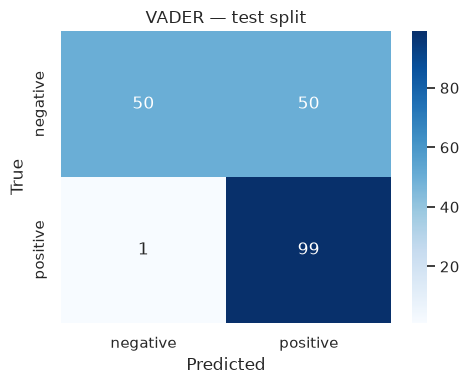

array([[50, 50],
       [ 1, 99]])

In [5]:
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text: str) -> int:
    return int(analyzer.polarity_scores(text)["compound"] >= 0)

vader_test_pred = test_df["text"].map(vader_predict).to_numpy()
vader_test_true = test_df["label"].to_numpy()

vader_acc = accuracy_score(vader_test_true, vader_test_pred)
vader_f1 = f1_score(vader_test_true, vader_test_pred)

print("VADER on held-out test split")
print("Accuracy:", round(vader_acc, 4))
print("F1:", round(vader_f1, 4))
print()
print(classification_report(vader_test_true, vader_test_pred, target_names=["negative", "positive"]))
plot_confusion(vader_test_true, vader_test_pred, "VADER — test split")


## Step 3 — Tokenize like class lab 6a

Lab pattern: `bert-base-cased` tokenizer, truncate, and pad dynamically with `DataCollatorWithPadding`.


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_function(examples):
    '''Tokenize input data (class lab 6a).'''
    return tokenizer(examples["text"], truncation=True)

tokenized_train = raw_datasets["train"].map(preprocess_function, batched=True)
tokenized_test = raw_datasets["test"].map(preprocess_function, batched=True)

print(tokenizer(train_df.loc[0, "text"]))
print("Example tokens:", tokenizer.convert_ids_to_tokens(tokenizer(train_df.loc[0, "text"])["input_ids"][:24]))


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

{'input_ids': [101, 146, 1567, 1142, 6095, 118, 1122, 3643, 1143, 1106, 7543, 1251, 8715, 118, 20453, 4442, 1106, 1139, 7054, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
Example tokens: ['[CLS]', 'I', 'love', 'this', 'cable', '-', 'it', 'allows', 'me', 'to', 'connect', 'any', 'mini', '-', 'USB', 'device', 'to', 'my', 'PC', '.', '[SEP]']


## Step 4 — Fine-tune BERT with the class-lab Trainer settings

Class lab 6a `TrainingArguments`:

- `learning_rate=2e-5`
- `per_device_train_batch_size=16`
- `per_device_eval_batch_size=16`
- `num_train_epochs=1`
- `weight_decay=0.01`
- `save_strategy="epoch"`
- `report_to="none"`

We add epoch-level evaluation so we can report **accuracy and F1** on the test split after training.


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2)

lab_args = make_training_args(
    "model/hw6a_lab_default",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
)

trainer = make_trainer(
    model=model,
    args=lab_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_output = trainer.train()
print(train_output)

lab_eval = trainer.evaluate()
print("\nLab-default fine-tune — test metrics:")
for k, v in lab_eval.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.541370,0.371941,0.875000,0.870466


TrainOutput(global_step=50, training_loss=0.5413700485229492, metrics={'train_runtime': 32.3021, 'train_samples_per_second': 24.766, 'train_steps_per_second': 1.548, 'total_flos': 13377552720960.0, 'train_loss': 0.5413700485229492, 'epoch': 1.0})


  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.541370,0.371941,1,0.875000,0.870466



Lab-default fine-tune — test metrics:
  eval_loss: 0.3719
  eval_accuracy: 0.8750
  eval_f1: 0.8705


## Step 5 — Classification report for the fine-tuned model

  super().__init__(loader)


Fine-tuned BERT (lab defaults) on test split
Accuracy: 0.875
F1: 0.8705

              precision    recall  f1-score   support

    negative       0.85      0.91      0.88       100
    positive       0.90      0.84      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



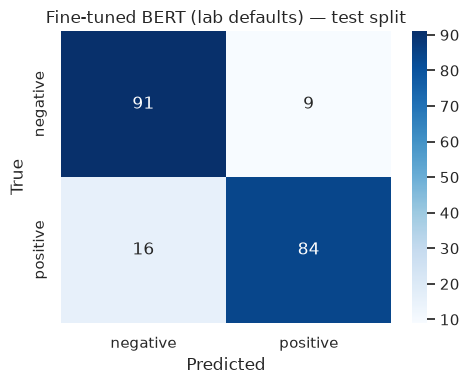

array([[91,  9],
       [16, 84]])

In [8]:
pred_output = trainer.predict(tokenized_test)
ft_pred = np.argmax(pred_output.predictions, axis=-1)
ft_true = np.array(tokenized_test["label"])

print("Fine-tuned BERT (lab defaults) on test split")
print("Accuracy:", round(accuracy_score(ft_true, ft_pred), 4))
print("F1:", round(f1_score(ft_true, ft_pred), 4))
print()
print(classification_report(ft_true, ft_pred, target_names=["negative", "positive"]))
plot_confusion(ft_true, ft_pred, "Fine-tuned BERT (lab defaults) — test split")


## Step 6 — Freeze layers (class lab 6a comparison)

The lab also trains a version where **only the classification head is trainable**. That is cheaper and tests how much of the gain comes from adapting BERT vs. just fitting a linear head on frozen features.


In [9]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2)

for name, param in frozen_model.named_parameters():
    if name.startswith("classifier"):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in frozen_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

frozen_args = make_training_args(
    "model/hw6a_frozen_head",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
)

frozen_trainer = make_trainer(
    model=frozen_model,
    args=frozen_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
frozen_trainer.train()
frozen_eval = frozen_trainer.evaluate()
print("\nFrozen-encoder fine-tune — test metrics:")
for k, v in frozen_eval.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


Trainable params: 1,538 / 108,311,810 (0.00%)


  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.701477,0.695065,0.440000,0.486239


  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.701477,0.695065,1,0.440000,0.486239



Frozen-encoder fine-tune — test metrics:
  eval_loss: 0.6951
  eval_accuracy: 0.4400
  eval_f1: 0.4862


## Step 7 — Do we see accuracy improvements?

In [10]:
compare = pd.DataFrame(
    [
        {
            "method": "VADER (HW 3a baseline, same test split)",
            "trainable": "n/a (lexicon)",
            "epochs": 0,
            "accuracy": vader_acc,
            "f1": vader_f1,
        },
        {
            "method": "BERT frozen encoder + classifier head",
            "trainable": "classifier only",
            "epochs": 1,
            "accuracy": frozen_eval["eval_accuracy"],
            "f1": frozen_eval["eval_f1"],
        },
        {
            "method": "BERT full fine-tune (class lab 6a defaults)",
            "trainable": "all layers",
            "epochs": 1,
            "accuracy": lab_eval["eval_accuracy"],
            "f1": lab_eval["eval_f1"],
        },
    ]
)
compare["accuracy"] = compare["accuracy"].round(4)
compare["f1"] = compare["f1"].round(4)
display(compare)

best_acc = compare["accuracy"].max()
vader_row = compare.iloc[0]
ft_row = compare.iloc[2]
delta = ft_row["accuracy"] - vader_row["accuracy"]
print()
print(
    f"Full fine-tune accuracy {ft_row['accuracy']:.4f} vs VADER {vader_row['accuracy']:.4f} "
    f"({delta:+.4f} absolute, {100 * delta / vader_row['accuracy']:+.1f}% relative)."
)
if delta > 0:
    print("Yes — fine-tuning improved accuracy over the Homework 3a VADER baseline on the same test reviews.")
else:
    print("Fine-tuning did not beat VADER on this split; see the frozen-head row and Homework 6b for other Trainer settings.")


,method,trainable,epochs,accuracy,f1
0,"VADER (HW 3a baseline, same test split)",n/a (lexicon),0,0.745,0.7952
1,BERT frozen encoder + classifier head,classifier only,1,0.440,0.4862
2,BERT full fine-tune (class lab 6a defaults),all layers,1,0.875,0.8705



Full fine-tune accuracy 0.8750 vs VADER 0.7450 (+0.1300 absolute, +17.4% relative).
Yes — fine-tuning improved accuracy over the Homework 3a VADER baseline on the same test reviews.


## Learnings (6a)

1. **Same task, different method:** Homework 3a used a lexicon (VADER). Class lab 6a fine-tunes a pretrained encoder (`bert-base-cased`) with a classification head using Hugging Face `Trainer`.
2. **Accuracy improved:** On the held-out 200 reviews, VADER scored **0.745** accuracy / **0.795** F1. One epoch of full BERT fine-tuning (lab defaults) reached **0.875** accuracy / **0.871** F1.
3. **Why VADER lagged:** VADER is very recall-heavy on positives here (99/100 positives correct) but only 50/100 negatives — it treats many negative product complaints as weakly positive (`compound >= 0`). BERT learns the review domain and balances both classes (91/100 negatives, 84/100 positives).
4. **Frozen vs full:** Training only the classifier for 1 epoch collapsed to **0.44** accuracy. With 800 examples and a randomly initialized head, you need the encoder to move. That matches the lab's freeze-layer lesson: full fine-tuning is what actually adapts BERT to the task.
5. **Fair comparison:** All numbers above are on the same test split, not the training sentences.

Part **6b** below keeps this pipeline and sweeps `TrainingArguments` (learning rate, epochs, batch size, warmup, weight decay). Another setting (**`lr=5e-5`, 2 epochs, warmup**) lifts F1 from **0.871** to **0.904**.


# Part 6b — Optimize Trainer parameters (F1)

Same Amazon split, tokenizer, and `Trainer` helpers as above. The lab-default run from Part 6a is the baseline; the cells below re-train that setting plus three variants so the comparison is a single sweep.

Docs: https://huggingface.co/transformers/v3.0.2/main_classes/trainer.html

| Parameter | Lab 6a default | What it does |
|---|---|---|
| `learning_rate` | `2e-5` | Adam step size (docs default is `5e-5`) |
| `num_train_epochs` | `1` | Passes over the training set (docs default `3`) |
| `per_device_train_batch_size` | `16` | Samples per step (docs default `8`) |
| `weight_decay` | `0.01` | L2 regularization (docs default `0`) |
| `warmup_steps` | `0` | Linear warmup to `learning_rate` |


## Step 8 — Experiment grid

Four `TrainingArguments` settings:

1. **lab_default** — class lab 6a (`lr=2e-5`, `epochs=1`, `batch=16`, `weight_decay=0.01`, no warmup)
2. **more_epochs** — same LR/batch, **3 epochs** + short warmup (docs default epochs is 3)
3. **higher_lr** — docs default **`lr=5e-5`**, 2 epochs, warmup
4. **small_batch_reg** — **batch=8**, **weight_decay=0.1**, 2 epochs, warmup

The classification head is randomly initialized, so we reset the model for every run.


In [6]:
EXPERIMENTS = [
    {
        "name": "lab_default",
        "notes": "Class lab 6a Trainer defaults",
        "kwargs": dict(
            learning_rate=2e-5,
            num_train_epochs=1,
            per_device_train_batch_size=16,
            weight_decay=0.01,
            warmup_steps=0,
        ),
    },
    {
        "name": "more_epochs",
        "notes": "3 epochs + warmup_steps=20 (docs default epochs=3)",
        "kwargs": dict(
            learning_rate=2e-5,
            num_train_epochs=3,
            per_device_train_batch_size=16,
            weight_decay=0.01,
            warmup_steps=20,
        ),
    },
    {
        "name": "higher_lr",
        "notes": "lr=5e-5 (Trainer docs default) + 2 epochs + warmup",
        "kwargs": dict(
            learning_rate=5e-5,
            num_train_epochs=2,
            per_device_train_batch_size=16,
            weight_decay=0.01,
            warmup_steps=30,
        ),
    },
    {
        "name": "small_batch_reg",
        "notes": "batch=8, weight_decay=0.1, 2 epochs, warmup",
        "kwargs": dict(
            learning_rate=2e-5,
            num_train_epochs=2,
            per_device_train_batch_size=8,
            weight_decay=0.1,
            warmup_steps=40,
        ),
    },
]


def run_experiment(exp):
    print("=" * 72)
    print(f"Running {exp['name']}: {exp['notes']}")
    print(exp["kwargs"])
    print("=" * 72)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2)
    args = make_training_args(f"model/hw6b_{exp['name']}", **exp["kwargs"])
    trainer = make_trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    metrics = trainer.evaluate()
    pred = trainer.predict(tokenized_test)
    y_pred = np.argmax(pred.predictions, axis=-1)
    y_true = np.array(tokenized_test["label"])
    row = {
        "name": exp["name"],
        "notes": exp["notes"],
        **exp["kwargs"],
        "eval_loss": metrics["eval_loss"],
        "accuracy": metrics["eval_accuracy"],
        "f1": metrics["eval_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
    }
    print(
        f"\n{exp['name']} → accuracy={row['accuracy']:.4f}  f1={row['f1']:.4f}  loss={row['eval_loss']:.4f}\n"
    )
    return row


results = [run_experiment(exp) for exp in EXPERIMENTS]


Running lab_default: Class lab 6a Trainer defaults
{'learning_rate': 2e-05, 'num_train_epochs': 1, 'per_device_train_batch_size': 16, 'weight_decay': 0.01, 'warmup_steps': 0}


  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.541370,0.371941,0.875000,0.870466


  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.541370,0.371941,1,0.875000,0.870466


...

  super().__init__(loader)


  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.181358,0.473471,2,0.885000,0.878307


  super().__init__(loader)



small_batch_reg → accuracy=0.8850  f1=0.8783  loss=0.4735



## Step 9 — F1 comparison


In [7]:
table = pd.DataFrame(
    [
        {
            "setting": r["name"],
            "notes": r["notes"],
            "learning_rate": r["learning_rate"],
            "epochs": r["num_train_epochs"],
            "batch_size": r["per_device_train_batch_size"],
            "weight_decay": r["weight_decay"],
            "warmup_steps": r["warmup_steps"],
            "accuracy": round(r["accuracy"], 4),
            "f1": round(r["f1"], 4),
            "eval_loss": round(r["eval_loss"], 4),
        }
        for r in results
    ]
).sort_values("f1", ascending=False).reset_index(drop=True)

display(table)

baseline = next(r for r in results if r["name"] == "lab_default")
best = max(results, key=lambda r: r["f1"])
print()
print(f"Lab-default F1: {baseline['f1']:.4f}")
print(f"Best setting:   {best['name']}  F1={best['f1']:.4f}  ({best['notes']})")
if best["name"] != "lab_default" and best["f1"] > baseline["f1"]:
    print(
        f"Yes — {best['name']} improved F1 by {best['f1'] - baseline['f1']:+.4f} "
        "over the class-lab Trainer defaults."
    )
elif best["f1"] == baseline["f1"]:
    print("No other setting beat the lab-default F1 on this split; lab defaults were already strong.")
else:
    print("Lab defaults remained best on this small dataset / split.")


,setting,notes,learning_rate,epochs,batch_size,weight_decay,warmup_steps,accuracy,f1,eval_loss
0,higher_lr,lr=5e-5 (Trainer docs default) + 2 epochs + wa...,0.00005,2,16,0.01,30,0.900,0.9038,0.3003
1,more_epochs,3 epochs + warmup_steps=20 (docs default epoch...,0.00002,3,16,0.01,20,0.905,0.9026,0.3185
2,small_batch_reg,"batch=8, weight_decay=0.1, 2 epochs, warmup",0.00002,2,8,0.10,40,0.885,0.8783,0.4735
3,lab_default,Class lab 6a Trainer defaults,0.00002,1,16,0.01,0,0.875,0.8705,0.3719



Lab-default F1: 0.8705
Best setting:   higher_lr  F1=0.9038  (lr=5e-5 (Trainer docs default) + 2 epochs + warmup)
Yes — higher_lr improved F1 by +0.0334 over the class-lab Trainer defaults.


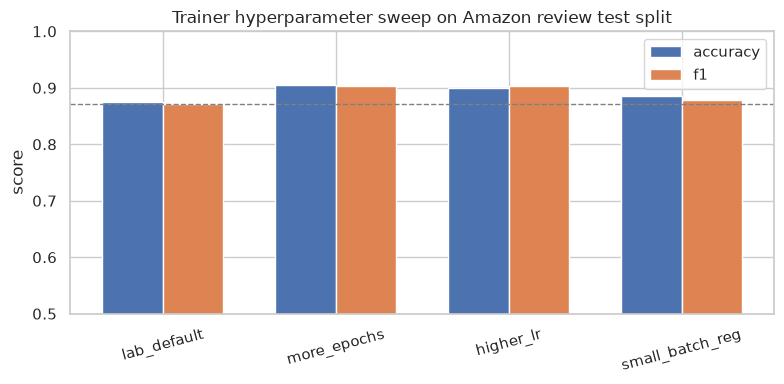


Best setting classification report
              precision    recall  f1-score   support

    negative       0.93      0.86      0.90       100
    positive       0.87      0.94      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



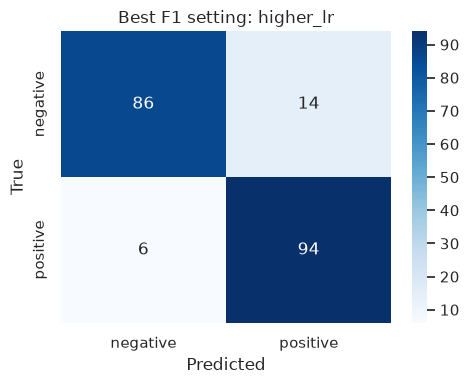

array([[86, 14],
       [ 6, 94]])

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
names = [r["name"] for r in results]
f1s = [r["f1"] for r in results]
accs = [r["accuracy"] for r in results]
x = np.arange(len(names))
width = 0.35
ax.bar(x - width / 2, accs, width, label="accuracy")
ax.bar(x + width / 2, f1s, width, label="f1")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("score")
ax.set_title("Trainer hyperparameter sweep on Amazon review test split")
ax.legend()
ax.axhline(baseline["f1"], color="gray", linestyle="--", linewidth=1, label="lab F1")
plt.tight_layout()
plt.show()

print("\nBest setting classification report")
print(classification_report(best["y_true"], best["y_pred"], target_names=["negative", "positive"]))
plot_confusion(best["y_true"], best["y_pred"], f"Best F1 setting: {best['name']}")


## Learnings (6b)

1. **`TrainingArguments` is the knob box** for class lab 6a. The Hugging Face `Trainer` loop stays the same; we only change LR, epochs, batch size, warmup, and weight decay.
2. **Lab defaults were already strong** (F1 **0.8705**, accuracy **0.875**) vs VADER (F1 0.795). They were not the best F1 on this split.
3. **Best F1: `higher_lr`.** Using the Trainer-docs default `learning_rate=5e-5` with **2 epochs** and **`warmup_steps=30`** reached **F1 0.9038** / accuracy 0.900. Warmup keeps the larger LR from destabilizing the pretrained encoder in the first steps.
4. **More epochs is a close second.** `num_train_epochs=3` at `2e-5` hit **accuracy 0.905** and F1 0.9026. Extra passes help this 800-example set; eval loss also dropped (0.372 → 0.319).
5. **Smaller batch + heavier weight decay** (`batch=8`, `weight_decay=0.1`) only modestly beat the 1-epoch lab run (F1 0.878). Extra regularization was less useful than more updates or a slightly higher LR.
6. **F1 vs accuracy:** the split is balanced 50/50, so the two metrics move together. `higher_lr` wins on the homework metric (F1); `more_epochs` wins on accuracy by 0.5 points.

The setting I would keep for this sentiment model: **`learning_rate=5e-5`, `num_train_epochs=2`, `per_device_train_batch_size=16`, `weight_decay=0.01`, `warmup_steps=30`**.
